# Battle of the BNI-LIS

In [ ]:
# library imports
import numpy as np   
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import immunization_funcs as imf # this is where the immunization strategies are implemented, see immunization_funcs.py
import sim_funcs as sf # this contains the simulation sweeps
import analysis_funcs as af # this contains the functions for analyzing the results of the simulations, see analysis_funcs.py

In [6]:
# the result metrics we collected
METRICS = ["final_attack_ratio", "peak_prevalence", "duration"]
METRIC_LABELS = {
    "final_attack_ratio": "Final attack ratio",
    "peak_prevalence": "Peak prevalence",
    "duration": "Duration",
}
METRIC_TITLES = ["Final Attack Ratio", "Peak Prevalence", "Epidemic Duration"]

# Columns that encode ids of simulation reps- we average and then drop them
DROP_COLS = ["network_rep", "sir_rep", "imm_rep"]

# This well be for the columns listing the 'best' algorithms based on specific result metrics
# (used throughout compute_best_algorithms and plot_algo_heatmaps)
METRIC_MAP = {
    "alg_final":    "final_attack_ratio",
    "alg_peak":     "peak_prevalence",
    "alg_duration": "duration",
}

### Which BNI-LI function is the best?
We have 3 different versions of the BNI-LI algorithm, and each can run either with or without additional local probing, yielding 6 versions total. They are indexed as:

```Python
immunization_funcs = {  # dict of immunization functions
    'BNI-LI': imf.BNI_LI,
    'BNI-LI-local': lambda G, coverage: imf.BNI_LI(G, coverage, doLocalProbing=True),
    'BNI-LI-teleport': imf.BNI_LI_with_teleport,
    'BNI-LI-teleport-local': lambda G, coverage: imf.BNI_LI_with_teleport(G, coverage, doLocalProbing=True),
    'BNI-LI-random-trial': imf.BNI_LI_with_random_restarts,
    'BNI-LI-random-trial-local': lambda G, coverage: imf.BNI_LI_with_random_restarts(G, coverage, doLocalProbing=True),
    } 
```

So let's start by figuring out which one of these is the best version, based on the simulation data saved in `bni_li_sweep.parquet`.

In [7]:
bni_df = pd.read_parquet("results/bni_li_sweep.parquet")
print(bni_df.shape)
bni_df.head()

(1980000, 11)


,rewire_steps,network_rep,modularity,algorithm,coverage,beta,gamma,sir_rep,final_attack_ratio,peak_prevalence,duration
0,0,0,0.77999,BNI-LI,0.02,0.04,0.1,0,0.0045,0.0020,37.892353
1,0,0,0.77999,BNI-LI,0.02,0.04,0.1,1,0.0005,0.0005,2.170462
2,0,0,0.77999,BNI-LI,0.02,0.04,0.1,2,0.9030,0.2665,152.061050
3,0,0,0.77999,BNI-LI,0.02,0.04,0.1,3,0.9025,0.2555,131.536972
4,0,0,0.77999,BNI-LI,0.02,0.04,0.1,4,0.9190,0.2930,141.332062


First, let's average over the 100 SIR simulations for each constellation:

In [9]:
# average over SIR reps
# modularity is already a column in this dataset, so we group directly on it.
BNI_GROUP_COLS    = ["modularity", "algorithm", "coverage", "beta", "gamma"] # 
BNI_SCENARIO_COLS = ["modularity", "coverage", "beta", "gamma"]

bni_avg  = af.avg_over_reps(bni_df,
                         group_cols=BNI_GROUP_COLS,
                         drop_cols=["rewire_steps", "network_rep", "sir_rep"],
                         )

bni_best = af.compute_best_algorithms(bni_avg, BNI_SCENARIO_COLS, METRIC_MAP)
bni_best.head()

,modularity,coverage,beta,gamma,alg_final,alg_peak,alg_duration
0,0.77999,0.02,0.04,0.1,BNI-LI-random-trial-local,BNI-LI-random-trial-local,BNI-LI-random-trial-local
1,0.77999,0.02,0.04,0.2,BNI-LI-random-trial,BNI-LI-random-trial,BNI-LI-random-trial
2,0.77999,0.02,0.04,0.3,BNI-LI-random-trial,BNI-LI-random-trial,BNI-LI-teleport-local
3,0.77999,0.02,0.04,0.4,BNI-LI,BNI-LI,BNI-LI
4,0.77999,0.02,0.04,0.5,BNI-LI-teleport-local,BNI-LI-random-trial-local,BNI-LI-random-trial-local


Which algorithm is best? I went with the oversimplified method of checking which algorithm yields the best (lowest) values for each of the result metrics, and then counting which one wins the most often.

In [10]:
# Count how often each BNI-LI variant achieves the best (lowest) value per metric.
best_counts = (
    pd.DataFrame({
        metric: bni_best[out_col].value_counts()
        for out_col, metric in METRIC_MAP.items()
    })
    .fillna(0)
    .astype(int)
    .sort_values("final_attack_ratio", ascending=False)
)
best_counts

,final_attack_ratio,peak_prevalence,duration
BNI-LI-random-trial-local,932,976,681
BNI-LI-random-trial,820,858,630
BNI-LI,439,438,552
BNI-LI-local,413,385,479
BNI-LI-teleport-local,353,333,464
BNI-LI-teleport,343,310,494


For fun, let's also do the heatmaps to check what succeeds where!

Heatmap grid: 15 coverage levels × 11 modularity levels


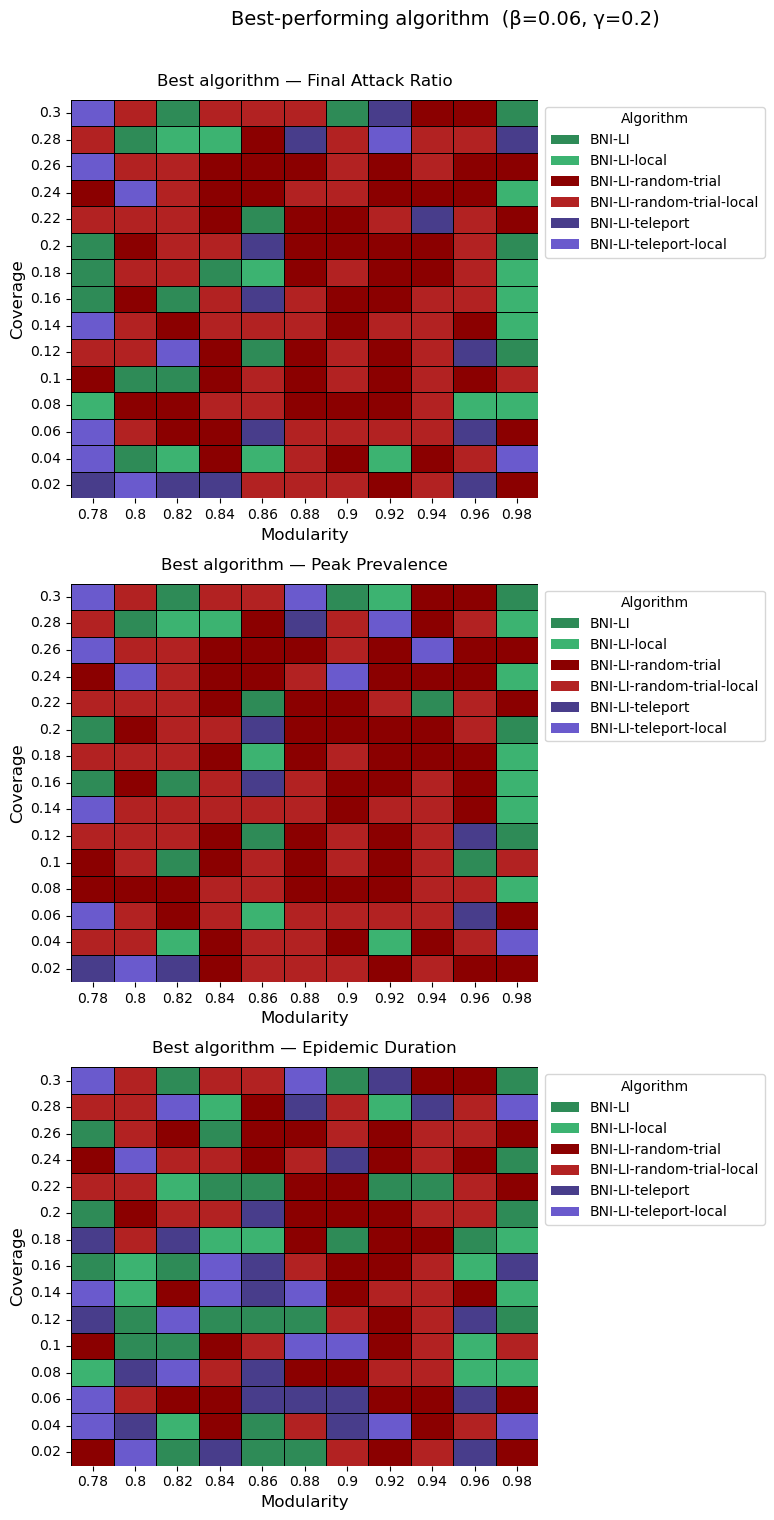

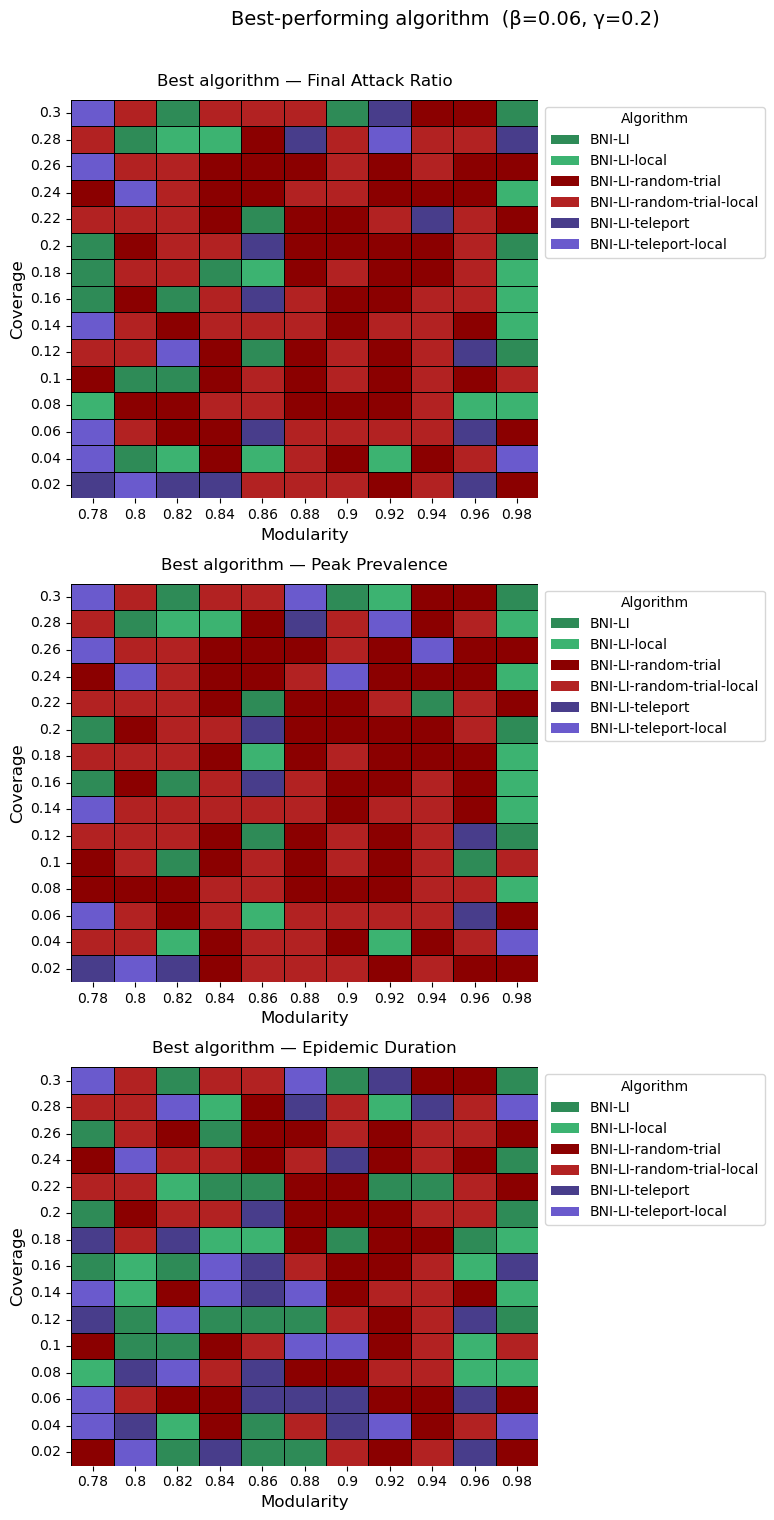

In [14]:
GAMMA_SLICE = 0.2
BETA_SLICE = 0.06

# Filter for the specific beta-gamma slice
best_filtered = (
    bni_best
    .loc[(bni_best["beta"] == BETA_SLICE) & (bni_best["gamma"] == GAMMA_SLICE)]
    .copy()
)
# round the modularity
best_filtered["modularity"] = best_filtered["modularity"].round(2)

# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best_filtered
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# ── Build shared colour encoding and draw the figure ─────────────────────────
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)

palette = ["seagreen", "mediumseagreen", "darkred", "firebrick", "darkslateblue", "slateblue"]
algo_to_code, palette, cmap, norm, legend_handles = af.make_color_encoding(all_algorithms, palette=palette)

af.plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    metric_map=METRIC_MAP,
    col_titles=METRIC_TITLES,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="bni_algo_heatmaps.png",
    annotate=False
)